# freezing 11/30

In [1]:
from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.helpers.experiment import *
from src.wiener_filter import *
from src.modeller import *

import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product




%load_ext autoreload 
%autoreload 2
%matplotlib widget

In [2]:
pre=100
post=100
session_path = '../data/co6/co6_10122023'
session = MPOptoClass(session_path, post=post)

love


# co6, 10/12/23

# 0. predicting CFA using just CFA PCs.

In [3]:
psth_bounds = copy.deepcopy(session.laser['laser_bounds'])
psth_bounds[:,0] = psth_bounds[:,0] - pre
psth_ctrl_bounds = copy.deepcopy(session.laser['ctrl_bounds'])
psth_ctrl_bounds[:,0] = psth_ctrl_bounds[:,0] - pre


omitLaserBounds = omitBoundInBounds(session.climbing_bounds, psth_bounds)
omitLaserBounds = omitBoundInBounds(omitLaserBounds, psth_ctrl_bounds)
omitLaserBounds = minimumBoundSize(omitLaserBounds)

(session.X, session.Y), pca_objs  = session.format_nlags_PCA(bounds=omitLaserBounds, binsize=10, nlags=10)
test = copy.deepcopy(session.X)
session.X = session.X[:, :session.num_CFA*10]
session.Y = session.Y[:, :session.num_CFA]
session.X_laser, session.Y_laser = session.transformat(pca_objs, bounds=psth_bounds)
session.X_laser = session.X_laser[:, :session.num_CFA*10]
session.Y_laser = session.Y_laser[:, :session.num_CFA]
session.X_ctrl, session.Y_ctrl = session.transformat(pca_objs, bounds=psth_ctrl_bounds)
session.X_ctrl = session.X_ctrl[:, :session.num_CFA*10]
session.Y_ctrl = session.Y_ctrl[:, :session.num_CFA]

0.12248674528483755


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


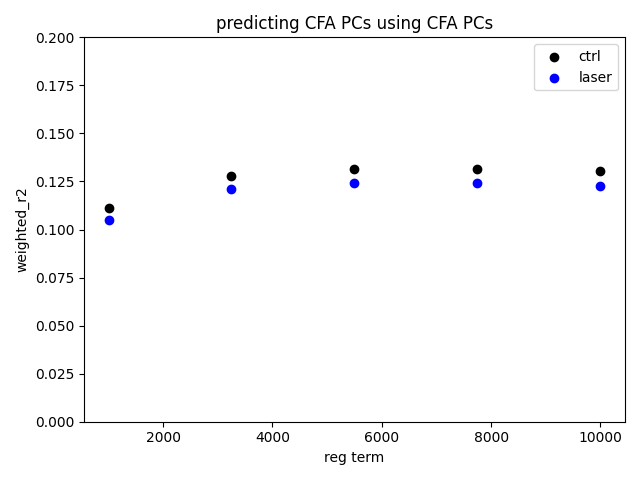

In [18]:
C_list = np.linspace(1000, 10000, 5)
fit_score_list = []
laser_score_list = []
ctrl_score_list = []
for c in C_list:
    h = train_wiener_filter(session.X, session.Y, C=c)
    fit = test_wiener_filter(session.X, h)
    fit_score = weighted_r2(session.Y, fit)
    predic_laser = test_wiener_filter(session.X_laser, h)
    predic_ctrl = test_wiener_filter(session.X_ctrl, h)
    laser_score_list.append(weighted_r2(session.Y_laser, predic_laser))
    ctrl_score_list.append(weighted_r2(session.Y_ctrl, predic_ctrl))

fig0, ax0 = plt.subplots()
ax0.scatter(C_list, ctrl_score_list, c='black', label='ctrl')
ax0.scatter(C_list, laser_score_list, c='blue', label='laser')
ax0.set_title('predicting CFA PCs using CFA PCs')
ax0.set_ylim([0,.2])
ax0.set_xlabel('reg term')
ax0.set_ylabel('weighted_r2')
ax0.legend()
fig0.tight_layout()
print(laser_score_list[-1])

# 1. sweeping through differential reg terms for CFA and RFA

In [11]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegs.pickle')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


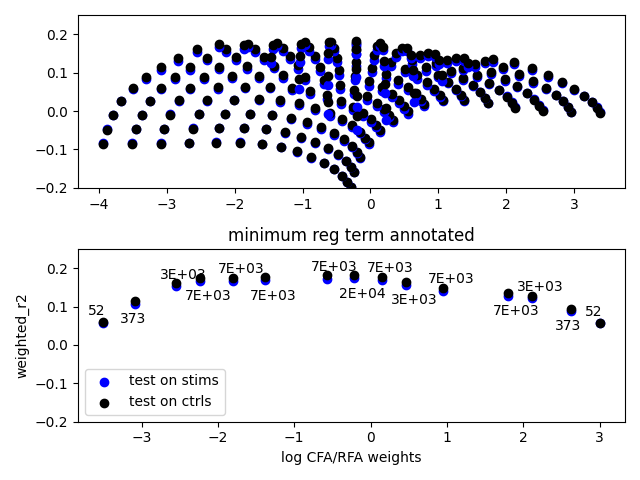

In [12]:
fig1, ax1 = plt.subplots(nrows=2)
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
fit_score_list = []
raw_weights_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    fit_score = o[3]
    
    temp = session.weights_per_region(h)
    raw_weights_list.append(temp)
    ratio = np.log10(temp[0]/temp[1])
    
    ratio_list.append(ratio)
    h_list.append(h)
    laser_score_list.append(laser_score)
    ctrl_score_list.append(ctrl_score)
    fit_score_list.append(fit_score)
    

    ax1[0].scatter(ratio, o[1], color='blue', label='stim')
    ax1[0].scatter(ratio, o[2], color='black', label='ctrl')
    #ax.scatter(ratio, o[3], color='gray')
#ax1[0].legend()

reg_terms = np.logspace(0,6,15)
reg_combos = np.array(list(product(reg_terms, reg_terms)))
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
fit_score_list = np.array(fit_score_list)
ratio_list = np.array(ratio_list)
raw_weights_list = np.array(raw_weights_list)

nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

reg_keep=[]
laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []
fit_score_keep = []
raw_weights_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    temp1 = raw_weights_list[indices]
    temp2 = temp1[keep]
    raw_weights_keep.append(temp2)
    
    #indices = np.argwhere(np.logical_and(condition1,condition2))
    #keep = np.argmax(ctrl_score_list[indices])
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 
    
    temp1 = fit_score_list[indices]
    temp2 = temp1[keep]
    fit_score_keep.append(temp2)
    
    temp1 = reg_combos[indices, :]
    temp2 = temp1[keep, :]
    reg_keep.append(temp2)

ax1[1].scatter(ratio_keep, laser_score_keep, color='blue', label='test on stims')
ax1[1].scatter(ratio_keep, ctrl_score_keep, color='black', label='test on ctrls')
ax1[1].legend()
ax1[0].set_ylim(-.2,.25)
ax1[1].set_ylim(-.2,.25)
ax1[1].set_xlabel('log CFA/RFA weights')
ax1[1].set_ylabel('weighted_r2')

reg_keep = np.squeeze(np.array(reg_keep))
for i, txt in enumerate(reg_keep):
    if i%2==0:
        offset=0.02
    else:
        offset=-0.05
    cfa_reg = np.min(txt)
    if cfa_reg > 1000:
        ax1[1].annotate(f"{cfa_reg:.0E}", (ratio_keep[i] - .2, laser_score_keep[i] + offset))
    else:
        ax1[1].annotate(str(round(cfa_reg)), (ratio_keep[i] - .2, laser_score_keep[i] + offset))
        
ax1[1].set_title('minimum reg term annotated')
fig1.tight_layout()
#ax1.scatter(ratio_keep, fit_score_keep, color='gray', label = 'fit score')

# 2. wider sweep, only keep properly regularized models

In [29]:
output = pload('/home/diya/Documents/mp_opto/picklejar/sweepRegs9.pickle')

In [39]:
ratio_list = []
h_list = []
laser_score_list = []
ctrl_score_list = []
fit_score_list = []
raw_weights_list = []
for idx, o in enumerate(output):
    h = o[0]
    laser_score = o[1]
    ctrl_score = o[2]
    fit_score = o[3]
    
    temp = session.weights_per_region(h)
    raw_weights_list.append(temp)
    ratio = np.log10(temp[0]/temp[1])
    

    
    if abs(laser_score - fit_score) < 1000:
        if laser_score > 0:
                ratio_list.append(ratio)
                h_list.append(h)
                laser_score_list.append(laser_score)
                ctrl_score_list.append(ctrl_score)
                fit_score_list.append(fit_score)
                
laser_score_list = np.array(laser_score_list)
ctrl_score_list = np.array(ctrl_score_list)
ratio_list = np.array(ratio_list)

In [40]:
nada, bin_ratio_edges = np.histogram(ratio_list, bins=15)

reg_keep=[]
laser_score_keep = []
ctrl_score_keep = []
ratio_keep = []
fit_score_keep = []
raw_weights_keep = []

for i in range(bin_ratio_edges.size - 1):
    condition1 = ratio_list > bin_ratio_edges[i]
    condition2 = ratio_list < bin_ratio_edges[i+1]
    
    indices = np.argwhere(np.logical_and(condition1,condition2))
    keep = np.argmax(laser_score_list[indices])
    temp1 = laser_score_list[indices]
    temp2 = temp1[keep]
    laser_score_keep.append(temp2)
    
    temp1 = ratio_list[indices]
    temp2 = temp1[keep]
    ratio_keep.append(temp2)
    
    temp1 = ctrl_score_list[indices]
    temp2 = temp1[keep]
    ctrl_score_keep.append(temp2) 

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


(0.0, 0.2)

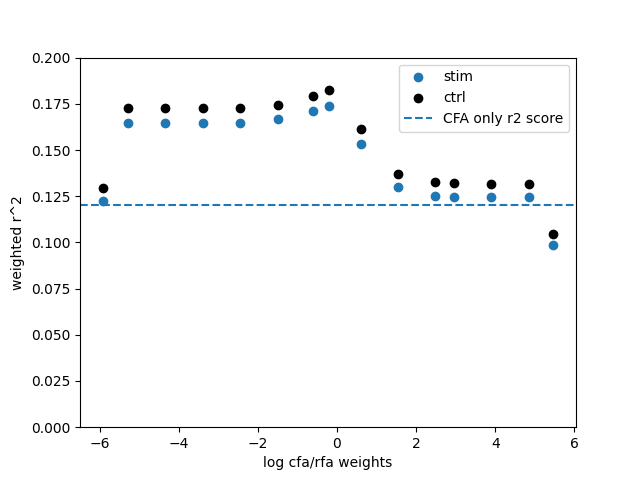

In [41]:
fig2, ax2 = plt.subplots()
ax2.scatter(ratio_keep, laser_score_keep, c='tab:blue', label='stim')
ax2.scatter(ratio_keep, ctrl_score_keep, c='black', label='ctrl')
ax2.set_ylabel('weighted r^2')
ax2.set_xlabel('log cfa/rfa weights')
ax2.axhline(.12, c='tab:blue', linestyle='--', label='CFA only r2 score')
ax2.legend()

ax2.set_ylim(0, .2)